# Group 1: RFM

## Importation des bibliothéques

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import *
import warnings
warnings.filterwarnings("ignore")

In [39]:
data = pd.read_csv('donnees_ecommerce.csv', encoding="ISO-8859-1")

In [40]:
data.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom


## Data analysis

In [41]:
from analysis import description

In [42]:
description(data)

STATISTIQUES DESCRIPTIVES DU DATASET

Dimension du dataset: 541909 lignes x 8 colonnes

Lignes dupliquées: 5268 (0.97%)

Pourcentage de valeurs manquantes par colonne:
  CustomerID: 24.93%
  Description: 0.27%

Quantités négatives: 10624

Commandes annulées (InvoiceNo commençant par 'C'): 9288


{'dimension': (541909, 8),
 'pct_valeurs_manquantes': CustomerID     24.926694
 Description     0.268311
 StockCode       0.000000
 InvoiceNo       0.000000
 Quantity        0.000000
 InvoiceDate     0.000000
 UnitPrice       0.000000
 Country         0.000000
 dtype: float64,
 'lignes_dupliquees': np.int64(5268),
 'pct_lignes_dupliquees': np.float64(0.9721189350979592),
 'quantites_negatives': np.int64(10624),
 'commandes_annulees': np.int64(9288)}

In [43]:
starts_with_letter = data[data['StockCode'].str.match(r'^[A-Za-z]')]

print("Nombre de lignes :", len(starts_with_letter))
print(starts_with_letter[['StockCode', 'Description']].head(20))

Nombre de lignes : 2995
         StockCode     Description
45            POST         POSTAGE
141              D        Discount
386           POST         POSTAGE
1123          POST         POSTAGE
1423            C2        CARRIAGE
1814           DOT  DOTCOM POSTAGE
2239             M          Manual
2250             M          Manual
3041           DOT  DOTCOM POSTAGE
4406  BANK CHARGES    Bank Charges
5073          POST         POSTAGE
5258          POST         POSTAGE
5325          POST         POSTAGE
5369          POST         POSTAGE
5450           DOT  DOTCOM POSTAGE
5545           DOT  DOTCOM POSTAGE
5684             M          Manual
5685           DOT  DOTCOM POSTAGE
6165           DOT  DOTCOM POSTAGE
6602          POST         POSTAGE


***Les StockCode commençant par une lettre correspondent à des lignes logistiques, financières ou manuelles (frais de port, remises, charges), qui ne reflètent pas un choix produit du client. Ils ont donc été exclus afin d’éviter des règles d’association artificielles.***

## Data preprocessing

In [44]:
df = data.copy()

In [45]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df['Quantity'] > 0]
df['Description'] = df['Description'].str.strip()
df.dropna(axis=0, subset=['InvoiceNo', 'Description'], inplace=True)
df = df[df['StockCode'].str[0].str.isdigit()]

In [46]:
# Montant de la transaction
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

**Date de référence**

In [47]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"], errors="coerce")

In [48]:
date_ref = df["InvoiceDate"].max() + pd.Timedelta(days=1)
date_ref

Timestamp('2011-12-10 12:50:00')

**Calcul des indicateurs RFM**

In [49]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (date_ref - x.max()).days,  # Récence
    "InvoiceNo": "nunique",                               # Fréquence
    "TotalPrice": "sum"                                   # Montant
})

rfm.columns = ["Recence", "Frequence", "Montant"]
rfm.head()

,Recence,Frequence,Montant
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1437.24
12349.0,19,1,1457.55
12350.0,310,1,294.40


- **Récence (R)** : Analyse du temps écoulé depuis la dernière commande. Un score élevé ici indique un client actif, tandis qu'un score faible signale un risque de désabonnement (churn).

- **Fréquence (F)** : Mesure de la fidélité. Cela permet de distinguer les acheteurs occasionnels des "fans" de la marque.

- **Montant (M)** : Évaluation de la valeur monétaire totale. C'est l'indicateur direct de la contribution au chiffre d'affaires.

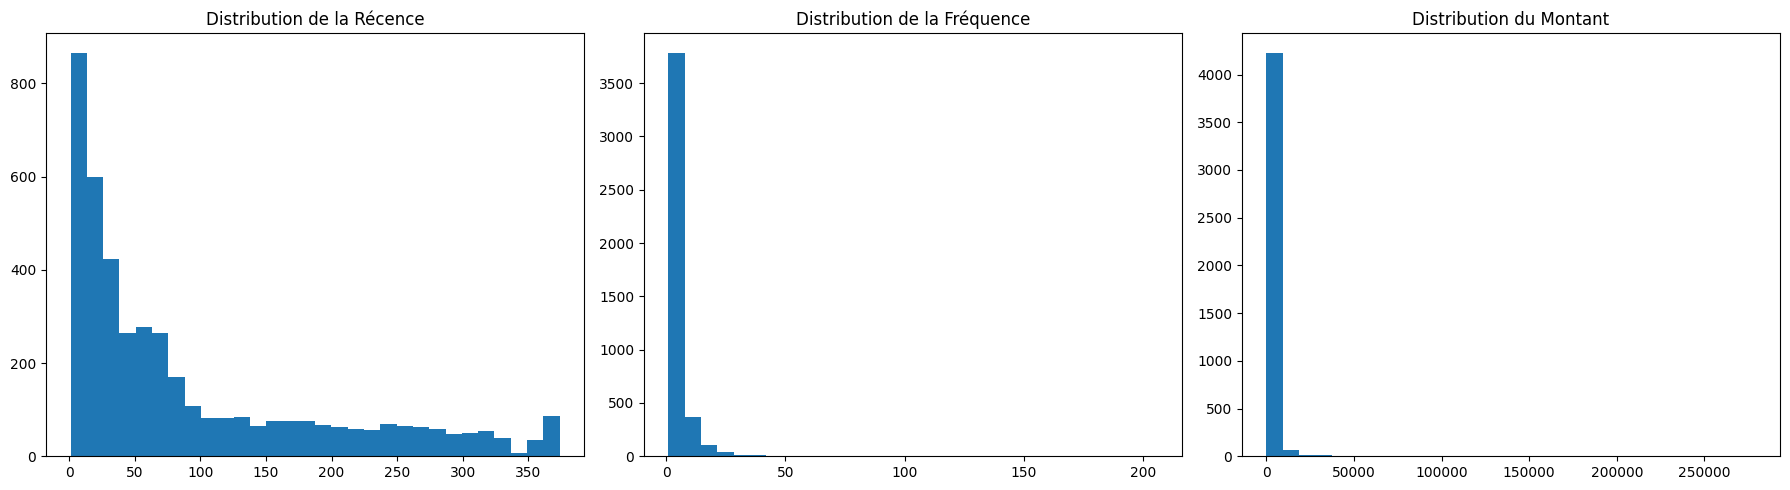

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(rfm["Recence"], bins=30)
axes[0].set_title("Distribution de la Récence")

axes[1].hist(rfm["Frequence"], bins=30)
axes[1].set_title("Distribution de la Fréquence")

axes[2].hist(rfm["Montant"], bins=30)
axes[2].set_title("Distribution du Montant")

plt.tight_layout()
plt.show()

**Calcul des scores RFM (quantiles)**

In [51]:
quantiles = rfm.quantile([0.25, 0.5, 0.75]).to_dict()
quantiles

{'Recence': {0.25: 18.0, 0.5: 51.0, 0.75: 143.0},
 'Frequence': {0.25: 1.0, 0.5: 2.0, 0.75: 5.0},
 'Montant': {0.25: 305.41, 0.5: 668.11, 0.75: 1631.475}}

In [52]:
def r_score(x, q):
    if x <= q["Recence"][0.25]:
        return 4
    elif x <= q["Recence"][0.5]:
        return 3
    elif x <= q["Recence"][0.75]:
        return 2
    else:
        return 1

def fm_score(x, col, q):
    if x <= q[col][0.25]:
        return 1
    elif x <= q[col][0.5]:
        return 2
    elif x <= q[col][0.75]:
        return 3
    else:
        return 4


**Application**

In [53]:
rfm["R_Score"] = rfm["Recence"].apply(r_score, q=quantiles)
rfm["F_Score"] = rfm["Frequence"].apply(fm_score, col="Frequence", q=quantiles)
rfm["M_Score"] = rfm["Montant"].apply(fm_score, col="Montant", q=quantiles)

**Score RFM global**

In [54]:
rfm["RFM_Score"] = (
    rfm["R_Score"].astype(str) +
    rfm["F_Score"].astype(str) +
    rfm["M_Score"].astype(str)
)

rfm.head()

,Recence,Frequence,Montant,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,114
12347.0,2,7,4310.00,4,4,4,444
12348.0,75,4,1437.24,2,3,3,233
12349.0,19,1,1457.55,3,1,3,313
12350.0,310,1,294.40,1,1,1,111


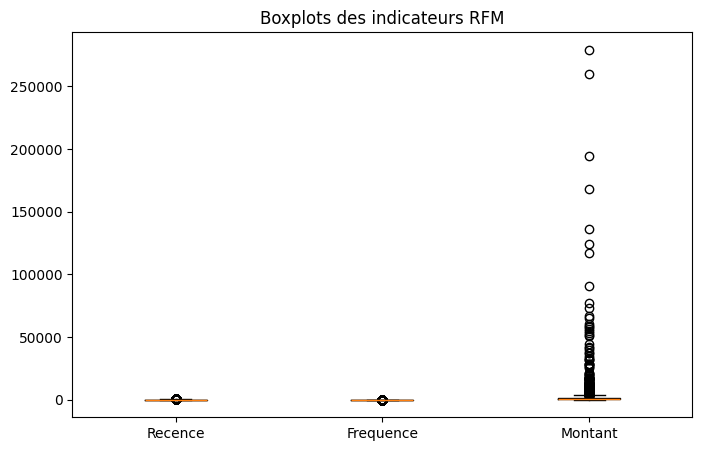

In [55]:
plt.figure(figsize=(8, 5))
plt.boxplot(
    [rfm["Recence"], rfm["Frequence"], rfm["Montant"]],
    labels=["Recence", "Frequence", "Montant"]
)
plt.title("Boxplots des indicateurs RFM")
plt.show()


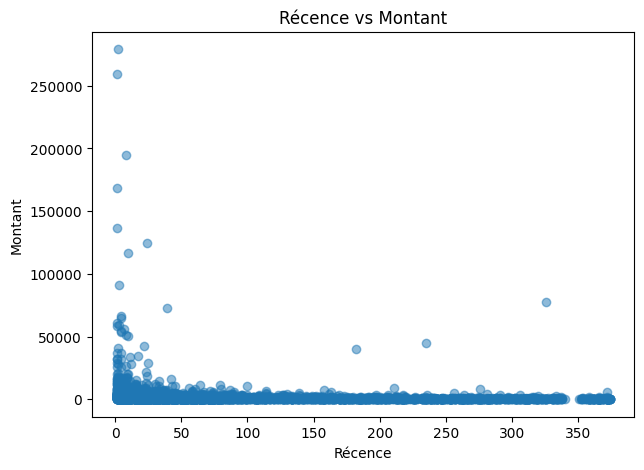

In [56]:
plt.figure(figsize=(7, 5))
plt.scatter(rfm["Recence"], rfm["Montant"], alpha=0.5)
plt.xlabel("Récence")
plt.ylabel("Montant")
plt.title("Récence vs Montant")
plt.show()


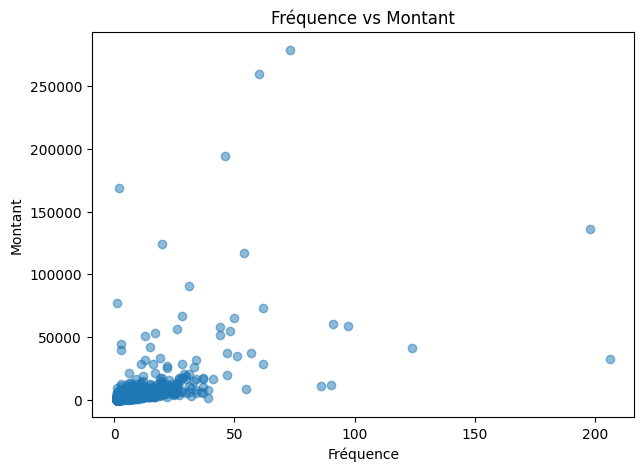

In [57]:
plt.figure(figsize=(7, 5))
plt.scatter(rfm["Frequence"], rfm["Montant"], alpha=0.5)
plt.xlabel("Fréquence")
plt.ylabel("Montant")
plt.title("Fréquence vs Montant")
plt.show()


**Segmentation des clients**

In [58]:
def segment_client(row):
    if row["RFM_Score"] >= "444":
        return "Meilleurs clients"
    elif row["R_Score"] >= 3 and row["F_Score"] >= 3:
        return "Clients fidèles"
    elif row["R_Score"] >= 3:
        return "Clients récents"
    elif row["F_Score"] >= 3:
        return "Clients réguliers"
    else:
        return "Clients à risque"

rfm["Segment"] = rfm.apply(segment_client, axis=1)


In [59]:
def rfm_segment(row):

    if row["R_Score"] == 4 and row["F_Score"] == 4:
        return "Champions"

    elif row["R_Score"] >= 3 and row["F_Score"] >= 3:
        return "Clients Fidèles"

    elif row["R_Score"] == 4 and row["F_Score"] <= 2:
        return "Nouveaux Clients"

    elif row["R_Score"] <= 2 and row["F_Score"] >= 3:
        return "Clients à Risque"

    elif row["R_Score"] == 1 and row["F_Score"] <= 2:
        return "Perdus"

    else:
        return "Client Standard"

rfm["Segment"] = rfm.apply(rfm_segment, axis=1)

In [60]:
rfm["Segment"].value_counts()

Segment
Client Standard     1119
Perdus               948
Clients Fidèles      916
Clients à Risque     555
Champions            527
Nouveaux Clients     270
Name: count, dtype: int64

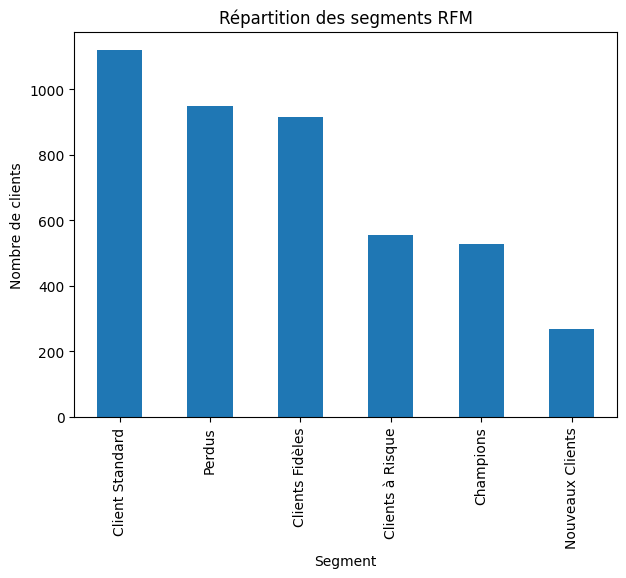

In [61]:
rfm["Segment"].value_counts().plot(kind="bar", figsize=(7, 5))
plt.title("Répartition des segments RFM")
plt.ylabel("Nombre de clients")
plt.show()

***La segmentation RFM permet d’identifier des profils clients distincts. Les champions sont à la fois récents et fréquents, tandis que les clients à risque étaient historiquement fidèles mais montrent une baisse d’activité. Cette segmentation aide à prioriser les actions marketing.***

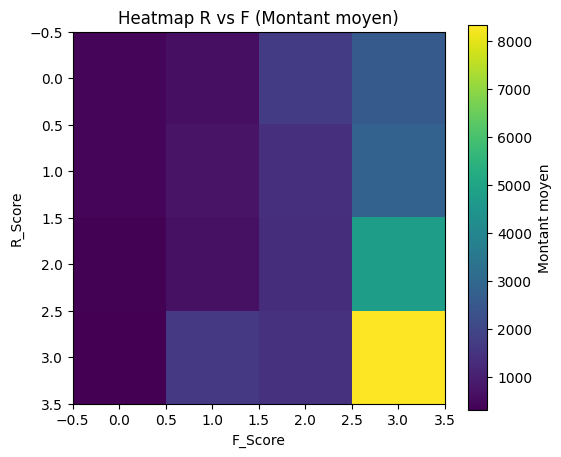

In [62]:
pivot_rf = rfm.pivot_table(
    index="R_Score",
    columns="F_Score",
    values="Montant",
    aggfunc="mean"
)

plt.figure(figsize=(6, 5))
plt.imshow(pivot_rf)
plt.colorbar(label="Montant moyen")
plt.xlabel("F_Score")
plt.ylabel("R_Score")
plt.title("Heatmap R vs F (Montant moyen)")
plt.show()


**Sauvegarde**

In [64]:
rfm.head()

,Recence,Frequence,Montant,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,Perdus
12347.0,2,7,4310.00,4,4,4,444,Champions
12348.0,75,4,1437.24,2,3,3,233,Clients à Risque
12349.0,19,1,1457.55,3,1,3,313,Client Standard
12350.0,310,1,294.40,1,1,1,111,Perdus


In [65]:
# Sauvegarde du modèle RFM
rfm.to_pickle("rfm_model.pkl")